In [2]:
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
import seaborn as sns
import src.comp.gc as gc_module
import os
import glob
import pandas as pd
from joblib import Parallel, delayed
import multiprocessing
from concurrent.futures import ProcessPoolExecutor
from typing import List, Optional
from difflib import SequenceMatcher
from pathlib import Path


In [3]:
def sync_file_lists(
    list1: List[Path], list2: List[Path]
) -> List[Optional[Path]]:
    """
    Syncs two lists of Paths based on the longest matching substring.

    For each path in list1, this function finds the path in list2 that
    shares the longest common substring with it. The result is a new list,
    ordered according to list1, containing the best-matching paths from list2.

    Args:
        list1: The reference list of Path objects. The order of this list is
               preserved in the output.
        list2: The list of Path objects to search for matches.

    Returns:
        A new list of Path objects. Each element at index `i` is the best
        match from `list2` for the element at `list1[i]`. If `list2` is empty
        or no match is found for an item, the corresponding entry will be None.
    """
    synced_list: List[Optional[Path]] = []

    # If list2 is empty, there can be no matches.
    if not list2:
        return [None] * len(list1)

    # For each path in the reference list...
    for path1 in list1:
        str_path1 = str(path1)
        best_match_path = None
        max_match_size = -1

        # ...find the best match from the second list.
        for path2 in list2:
            str_path2 = str(path2)
            
            # Use SequenceMatcher to find the longest contiguous matching block.
            matcher = SequenceMatcher(a=str_path1, b=str_path2, autojunk=False)
            match = matcher.find_longest_match()

            if match.size > max_match_size:
                max_match_size = match.size
                best_match_path = path2
        
        synced_list.append(best_match_path)

    return synced_list

In [4]:
cris_metadata = pd.read_csv("accessory_files/cris_metadata.csv")
pon_file_names = []
for i in range(22, 70):
    name = f"EE879{i:02d}"
    pon_file_names.append(name)

pon_file_names = cris_metadata[cris_metadata['disease'] == 'Healthy'].iloc[2:50]['ID'].tolist()  # 48 samples, since the first two are not cfDNA
healthy_file_names = cris_metadata[cris_metadata['disease'] == 'Healthy'].iloc[50:]['ID'].tolist()  # Remaining healthy samples
cancer_file_names = cris_metadata[(cris_metadata['disease'] == 'Breast cancer') | (cris_metadata['disease'] == 'Colorectal cancer')]['ID'].tolist()


In [5]:
# --- This part of your code remains unchanged ---
blacklist = pd.read_csv("accessory_files/hg38_GCcorrection_ExclusionList.merged.sorted.bed", sep='\t', header=None, names=['chrom', 'start', 'end', 'desc'])
# If centromer in desc, keep that row
blacklist = blacklist[blacklist['desc'].str.contains('centromer')]

def get_hg38_chrom_lengths():
    """Returns a dictionary of hg38 chromosome lengths for major chromosomes."""
    return {
        'chr1': 248956422, 'chr2': 242193529, 'chr3': 198295559,
        'chr4': 190214555, 'chr5': 181538259, 'chr6': 170805979,
        'chr7': 159345973, 'chr8': 145138636, 'chr9': 138394717,
        'chr10': 133797422, 'chr11': 135086622, 'chr12': 133275309,
        'chr13': 114364328, 'chr14': 107043718, 'chr15': 101991189,
        'chr16': 90338345, 'chr17': 83257441, 'chr18': 80373285,
        'chr19': 58617616, 'chr20': 64444167, 'chr21': 46709983,
        'chr22': 50818468, 'chrX': 156040895, 'chrY': 57227415
    }

def add_cumulative_position(df, chrom_lengths):
    """Adds a 'cumulative_pos' column to the dataframe for genome-wide plotting."""
    df['chrom'] = df['chrom'].astype(str)
    if not df['chrom'].iloc[0].startswith('chr'):
        df['chrom'] = 'chr' + df['chrom']
    
    chrom_offsets = {}
    current_offset = 0
    sorted_chroms = sorted(chrom_lengths.keys(), key=lambda x: int(x[3:]) if x[3:].isdigit() else ord(x[3:]))
    
    for chrom in sorted_chroms:
        chrom_offsets[chrom] = current_offset
        current_offset += chrom_lengths.get(chrom, 0)

    df['cumulative_pos'] = df.apply(
        lambda row: chrom_offsets.get(row['chrom'], 0) + row['start'], axis=1
    )
    return df, chrom_offsets

# --- This is where the main changes are ---

def process_file(file_path, features_to_agg):
    """
    Worker function: reads a single CSV file and extracts feature columns.
    This function will be executed in parallel for each file.
    """
    df = pd.read_csv(file_path)
    feature_data = {}
    for feature in features_to_agg:
        # Apply the same logic as in the original code
        if feature == 'mds':
            feature_data[feature] = df[feature].values * -1
        else:
            feature_data[feature] = df[feature].values
    return feature_data

def aggregate_data_from_folder(folder_path, features_to_agg, file_filter=None):
    """
    Loads all CSV files from a folder in parallel, aggregates specified features,
    and returns a dataframe with mean and std for each bin.
    """
    all_files = sorted(glob.glob(os.path.join(folder_path, '*tsv_BIN.csv')))

    if not all_files:
        return None
    
    if file_filter:
        all_files = sync_file_lists(file_filter, [Path(f) for f in all_files])
        print(f"Filtered to {len(all_files)} files after applying the filter.")

    # Use the first file to get the genomic coordinates template
    template_df = pd.read_csv(all_files[0])
    
    # Determine the number of CPU cores to use for parallel processing
    num_cores = multiprocessing.cpu_count()
    print(f"Loading {len(all_files)} samples from {folder_path} using {num_cores} cores...")

    # Use joblib to process files in parallel
    # `delayed` wraps the function call, and `Parallel` executes them
    results = Parallel(n_jobs=num_cores)(
        delayed(process_file)(f, features_to_agg) for f in tqdm(all_files)
    )
    
    # Reorganize the parallel results back into the original `data_list` structure
    data_list = {feature: [] for feature in features_to_agg}
    for item in results:
        for feature in features_to_agg:
            data_list[feature].append(item[feature])
            
    # Create the aggregated dataframe (this logic is unchanged)
    agg_df = template_df[['chrom', 'start', 'end']].copy()
    
    print("\nCalculating mean and standard deviation...")
    for feature in tqdm(features_to_agg):
        # Stack the arrays for efficient calculation
        feature_matrix = np.vstack(data_list[feature])
        print("Feature", feature, feature_matrix.shape)
        agg_df[f'{feature}_mean'] = np.nanmean(feature_matrix, axis=0)
        agg_df[f'{feature}_std'] = np.nanstd(feature_matrix, axis=0)

    return agg_df

# =================================================================================
# --- ✨ NEW FUNCTION: Load a single feature from all files in parallel ---
# =================================================================================

def _worker_load_feature(file_path, feature_name):
    """
    A simple worker function for parallel execution.
    Reads one CSV and returns just the one specified feature column as a NumPy array.
    """
    try:
        df = pd.read_csv(file_path, usecols=[feature_name])
        return df[feature_name].values
    except Exception as e:
        print(f"Error processing file {os.path.basename(file_path)}: {e}")
        return None

def load_feature_in_parallel(folder_path, feature_name, file_filter=None):
    """
    Loads a single feature from all matching CSV files in a folder in parallel.

    The key to maintaining order is sorting the file paths *before* parallelizing.
    The final array will have columns corresponding to the alphabetically sorted file names.

    Args:
        folder_path (str): The path to the directory containing the CSV files.
        feature_name (str): The name of the column (feature) to extract.
        file_filter (list, optional): A list of IDs to filter file names.

    Returns:
        np.ndarray: A 2D NumPy array of shape (n_samples, n_features), which in this
                    context is (number_of_bins, number_of_files). Returns None if no
                    files are found.
    """
    print(f"--- Loading feature '{feature_name}' in parallel ---")
    
    # 1. Find all relevant files and SORT them. This is critical for order.
    all_files = sorted(glob.glob(os.path.join(folder_path, '*tsv_BIN.csv')))
    if not all_files:
        print(f"Warning: No '*tsv_BIN.csv' files found in {folder_path}")
        return None

    if file_filter:
        all_files = sync_file_lists(file_filter, [Path(f) for f in all_files])
        print(f"Filtered to {len(all_files)} files after applying the filter.")

    # 3. Use ProcessPoolExecutor to load files in parallel.
    # It's a modern and clean way to manage a pool of processes.
    with ProcessPoolExecutor(max_workers=multiprocessing.cpu_count()) as executor:
        # The `executor.map` function applies the worker to each file path.
        # Importantly, it returns the results in the same order as the input.
        results = list(tqdm(executor.map(_worker_load_feature, all_files, [feature_name]*len(all_files)), total=len(all_files)))

    # Filter out any potential `None` results from failed file reads
    valid_results = [res for res in results if res is not None]
    if not valid_results:
        print("Error: Could not successfully load the feature from any file.")
        return None

    # 4. Stack the resulting 1D arrays into a single 2D array.
    # np.stack with axis=1 makes each file's data a new column.
    # The shape will be (rows_per_file, num_files).
    final_array = np.stack(valid_results, axis=1).T
    
    print(f"Successfully created array of shape: {final_array.shape}")
    return final_array

# --- Main execution block remains unchanged ---

# --- IMPORTANT ---
# Update this to the base directory containing your resolution folders
base_path = './extracted_features/' 

resolutions = ['100kb']
features_to_aggregate = ['fslr', 'fslr_coverage', 'griffin_diff', 'rcov', 'mwh', 'absolute_fragment_counts','relative_fragment_counts','absolute_short_fragments','absolute_long_fragments','mean_coverage','mean_coverage_short','mean_coverage_long','coverage_spread','gc_content','mean_fragment_gc_content','mean_fragment_gc_content_short','mean_fragment_gc_content_long','mds']
# features_to_aggregate += np.arange(100, 221, 1).astype(str).tolist()  # Adding '100' to '220' as strings

chrom_lengths = get_hg38_chrom_lengths()

print("--- Aggregating Data Across All Samples ---")

folder_path = os.path.join(base_path, 'biomart_10kb')
agg_pon = aggregate_data_from_folder(folder_path, features_to_aggregate, file_filter=pon_file_names)
agg_pon, chrom_offsets = add_cumulative_position(agg_pon, chrom_lengths)

agg_healthy = aggregate_data_from_folder(folder_path, features_to_aggregate, file_filter=healthy_file_names)
agg_healthy, chrom_offsets = add_cumulative_position(agg_healthy, chrom_lengths)

print("Successfully aggregated data")

feature_arrays_pon = {}
feature_arrays_healthy = {}
tss_features = ["fslr", "fslr_coverage", "griffin_diff", "rcov", "mwh"]
for feature_to_load in tss_features:
    feature_arrays_pon[feature_to_load] = load_feature_in_parallel(folder_path, feature_to_load, file_filter=pon_file_names)
    feature_arrays_healthy[feature_to_load] = load_feature_in_parallel(folder_path, feature_to_load, file_filter=healthy_file_names)
    print(f"Loaded feature '{feature_to_load}' with shape {feature_arrays_pon[feature_to_load].shape} for PON and {feature_arrays_healthy[feature_to_load].shape} for healthy samples.")


--- Aggregating Data Across All Samples ---
Filtered to 48 files after applying the filter.
Loading 48 samples from ./extracted_features/biomart_10kb using 4 cores...


100%|██████████| 48/48 [00:06<00:00,  7.34it/s]



Calculating mean and standard deviation...


 50%|█████     | 9/18 [00:00<00:00, 88.62it/s]

Feature fslr (48, 19376)
Feature fslr_coverage (48, 19376)
Feature griffin_diff (48, 19376)
Feature rcov (48, 19376)
Feature mwh (48, 19376)
Feature absolute_fragment_counts (48, 19376)
Feature relative_fragment_counts (48, 19376)
Feature absolute_short_fragments (48, 19376)
Feature absolute_long_fragments (48, 19376)
Feature mean_coverage (48, 19376)
Feature mean_coverage_short (48, 19376)
Feature mean_coverage_long (48, 19376)
Feature coverage_spread (48, 19376)
Feature gc_content (48, 19376)
Feature mean_fragment_gc_content (48, 19376)
Feature mean_fragment_gc_content_short (48, 19376)
Feature mean_fragment_gc_content_long (48, 19376)
Feature mds (48, 19376)


...

Successfully created array of shape: (212, 19376)
Loaded feature 'rcov' with shape (48, 19376) for PON and (212, 19376) for healthy samples.
--- Loading feature 'mwh' in parallel ---
Filtered to 48 files after applying the filter.


100%|██████████| 48/48 [00:15<00:00,  3.01it/s]


Successfully created array of shape: (48, 19376)
--- Loading feature 'mwh' in parallel ---
Filtered to 212 files after applying the filter.


100%|██████████| 212/212 [01:38<00:00,  2.14it/s]


Successfully created array of shape: (212, 19376)
Loaded feature 'mwh' with shape (48, 19376) for PON and (212, 19376) for healthy samples.


In [6]:
feature_arrays_pon['coverage'] = load_feature_in_parallel(folder_path, 'mean_coverage', file_filter=pon_file_names)

--- Loading feature 'mean_coverage' in parallel ---
Filtered to 48 files after applying the filter.


100%|██████████| 48/48 [00:16<00:00,  2.92it/s]

Successfully created array of shape: (48, 19376)


In [7]:
folder_path = os.path.join(base_path, 'biomart_10kb')

agg_cancer = aggregate_data_from_folder(folder_path, features_to_aggregate, file_filter=cancer_file_names)
agg_cancer, chrom_offsets = add_cumulative_position(agg_cancer, chrom_lengths)

print("Successfully aggregated data")
feature_arrays_cancer = {}
tss_features = ["fslr", "fslr_coverage", "griffin_diff", "rcov", "mwh"]
for feature_to_load in tss_features:
    feature_arrays_cancer[feature_to_load] = load_feature_in_parallel(folder_path, feature_to_load, file_filter=cancer_file_names)
    print(f"Loaded feature '{feature_to_load}' with shape {feature_arrays_pon[feature_to_load].shape} for PON, {feature_arrays_healthy[feature_to_load].shape} for healthy samples, and {feature_arrays_cancer[feature_to_load].shape} for cancer samples.")

Filtered to 81 files after applying the filter.
Loading 81 samples from ./extracted_features/biomart_10kb using 4 cores...


100%|██████████| 81/81 [00:47<00:00,  1.71it/s]



Calculating mean and standard deviation...


 22%|██▏       | 4/18 [00:00<00:00, 32.57it/s]

Feature fslr (81, 19376)
Feature fslr_coverage (81, 19376)
Feature griffin_diff (81, 19376)
Feature rcov (81, 19376)
Feature mwh (81, 19376)
Feature absolute_fragment_counts (81, 19376)
Feature relative_fragment_counts (81, 19376)
Feature absolute_short_fragments (81, 19376)


...

Successfully created array of shape: (81, 19376)
Loaded feature 'griffin_diff' with shape (48, 19376) for PON, (212, 19376) for healthy samples, and (81, 19376) for cancer samples.
--- Loading feature 'rcov' in parallel ---
Filtered to 81 files after applying the filter.


100%|██████████| 81/81 [00:04<00:00, 16.73it/s] 


Successfully created array of shape: (81, 19376)
Loaded feature 'rcov' with shape (48, 19376) for PON, (212, 19376) for healthy samples, and (81, 19376) for cancer samples.
--- Loading feature 'mwh' in parallel ---
Filtered to 81 files after applying the filter.


100%|██████████| 81/81 [00:08<00:00, 10.00it/s]


Successfully created array of shape: (81, 19376)
Loaded feature 'mwh' with shape (48, 19376) for PON, (212, 19376) for healthy samples, and (81, 19376) for cancer samples.


Outlier thresholds (mean): 0.6324 (lower) and 2.2222 (upper)
Outlier thresholds (std): 0.2380 (lower) and 0.6684 (upper)
Number of outlier bins (mean): 970
Number of outlier bins (std): 970
Number of overlapping outlier bins: 742


/tmp/ipykernel_50455/3690533638.py:65: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc='upper right')


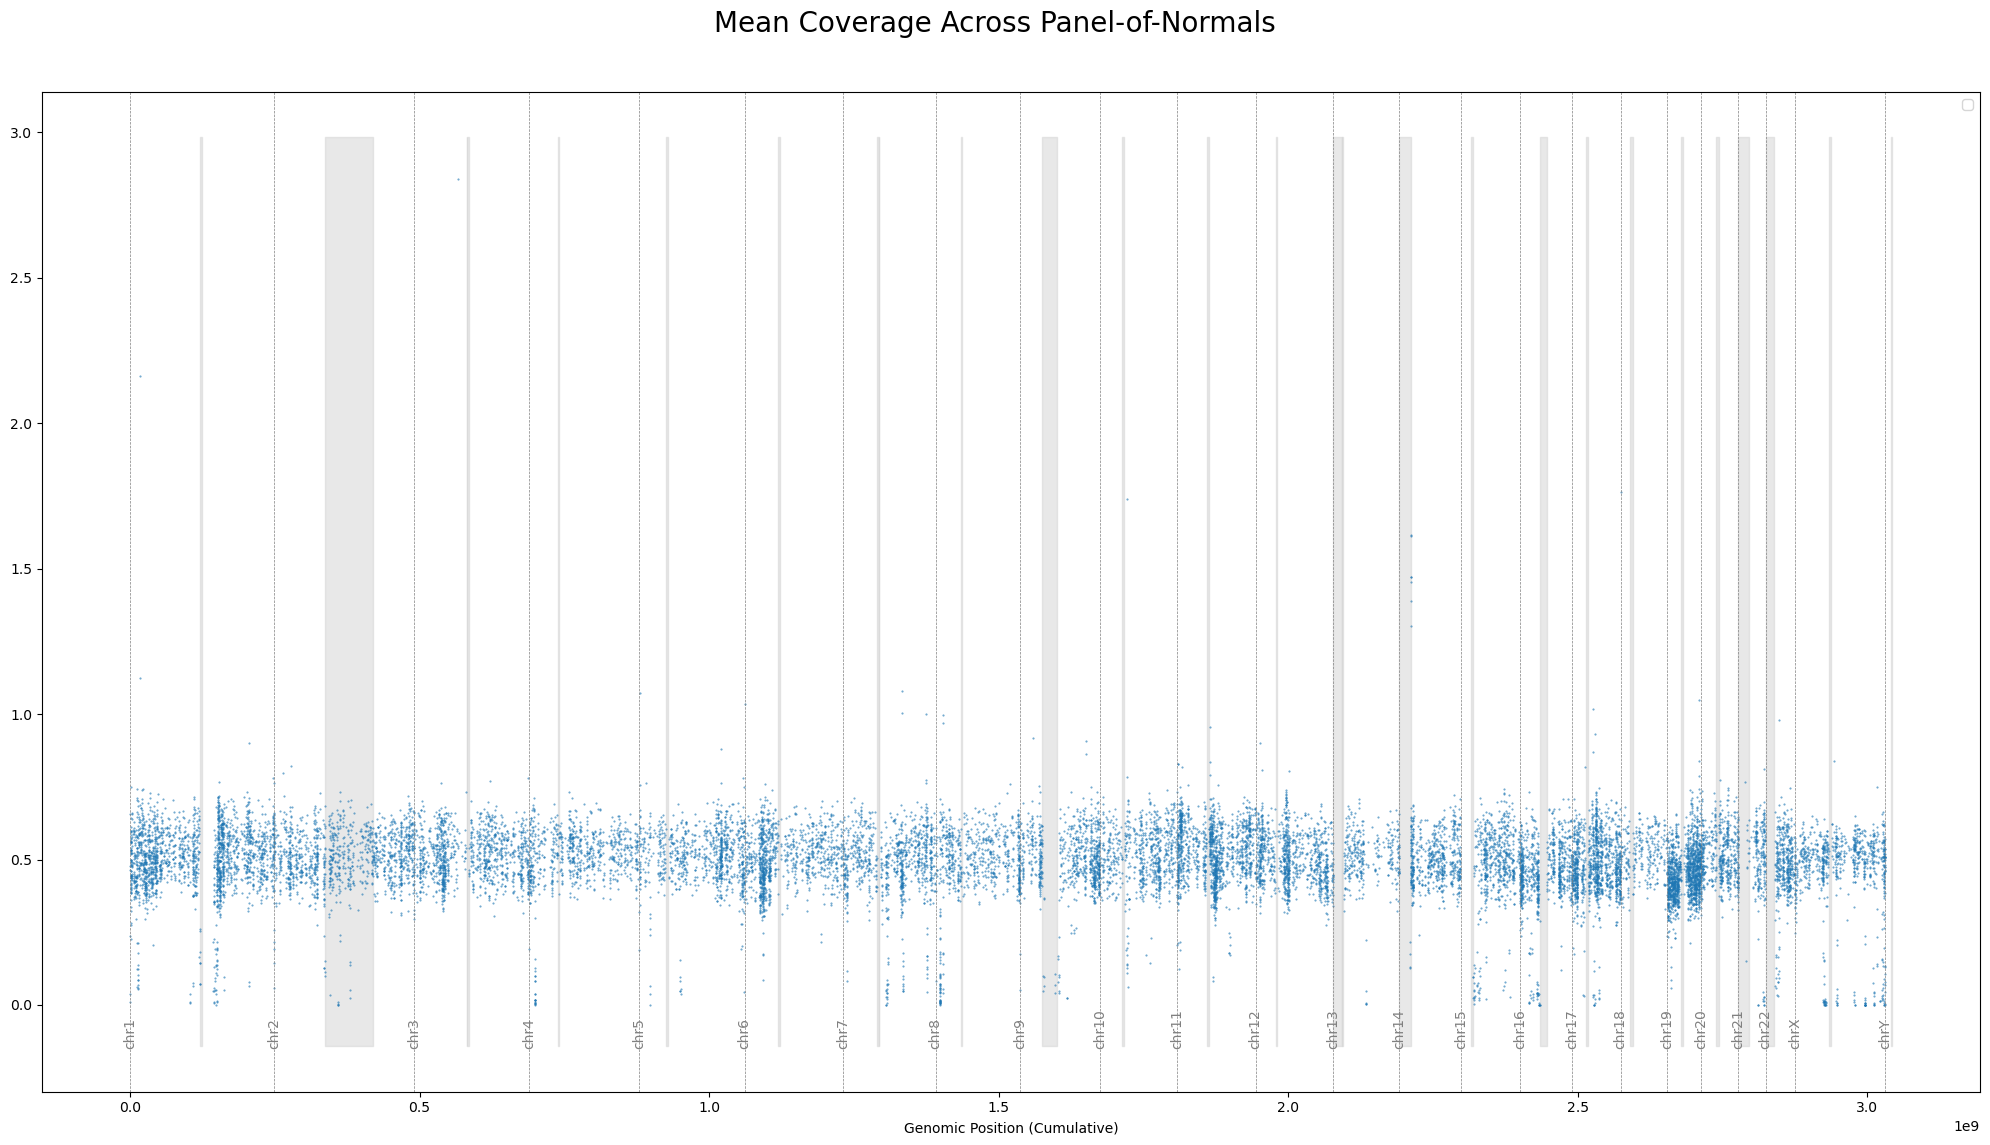

In [8]:
fig1 = plt.figure(figsize=(20, 12))
fig1.suptitle('Mean Coverage Across Panel-of-Normals', fontsize=20)
# for i, (res, df) in enumerate(aggregated_data_gc.items()):
plt.plot(agg_pon['cumulative_pos'], agg_pon['mean_coverage_std'], linewidth=0.8, alpha=0.7, linestyle='', marker='.', markersize=1)

# Identify the hotspot
# 1. Define quantiles for the lower 2.5% and upper 2.5%
lower_quantile = 0.025
upper_quantile = 0.975

# 2. Calculate the threshold values for both mean and std
lower_threshold_mean = agg_pon['mean_coverage_mean'].quantile(lower_quantile)
upper_threshold_mean = agg_pon['mean_coverage_mean'].quantile(upper_quantile)

lower_threshold_std = agg_pon['mean_coverage_std'].quantile(lower_quantile)
upper_threshold_std = agg_pon['mean_coverage_std'].quantile(upper_quantile)

# 3. Identify indices for outliers (below the lower OR above the upper threshold)
outlier_indices_mean = agg_pon[
    (agg_pon['mean_coverage_mean'] <= lower_threshold_mean) | 
    (agg_pon['mean_coverage_mean'] >= upper_threshold_mean)
].index

outlier_indices_std = agg_pon[
    (agg_pon['mean_coverage_std'] <= lower_threshold_std) | 
    (agg_pon['mean_coverage_std'] >= upper_threshold_std)
].index

# Find where both metrics are outliers
overlap_indices = outlier_indices_mean.intersection(outlier_indices_std)

print(f"Outlier thresholds (mean): {lower_threshold_mean:.4f} (lower) and {upper_threshold_mean:.4f} (upper)")
print(f"Outlier thresholds (std): {lower_threshold_std:.4f} (lower) and {upper_threshold_std:.4f} (upper)")
print(f"Number of outlier bins (mean): {len(outlier_indices_mean)}")
print(f"Number of outlier bins (std): {len(outlier_indices_std)}")
print(f"Number of overlapping outlier bins: {len(overlap_indices)}")


# 4. Highlight the outlier regions (updated variable names from hotspot to outlier)
# plt.plot(agg_pon.loc[outlier_indices_mean, 'cumulative_pos'], agg_pon.loc[outlier_indices_mean, 'mean_coverage_mean'], linestyle='', marker='o', color='red', markersize=2, label='Outlier (mean)')
# plt.plot(agg_pon.loc[outlier_indices_std, 'cumulative_pos'], agg_pon.loc[outlier_indices_std, 'mean_coverage_mean'], linestyle='', marker='x', color='orange', markersize=2, label='Outlier (std)')
# plt.plot(agg_pon.loc[overlap_indices, 'cumulative_pos'], agg_pon.loc[overlap_indices, 'mean_coverage_mean'], linestyle='', marker='*', color='purple', markersize=4, label='Outlier (overlap)')

chr_sizes = get_hg38_chrom_lengths()
chr_labels = list(chr_sizes.keys())
ax_ylim = plt.ylim()
for offset_idx, offset in enumerate(chrom_offsets.values()):
    plt.axvline(offset, color='grey', ls='--', lw=0.5)
    # Add the chromosome labels
    if offset_idx < len(chr_labels):
        plt.text(offset, ax_ylim[0], chr_labels[offset_idx], color='grey', fontsize=10, ha='center', rotation=90)

# Colour in the centromeres
for _, row in blacklist.iterrows():
    centromere_chrom = row['chrom']
    centromere_start = row['start'] + chrom_offsets[centromere_chrom]
    centromere_end = row['end'] + chrom_offsets[centromere_chrom]
    plt.fill_betweenx(ax_ylim, centromere_start, centromere_end, color='lightgrey', alpha=0.5)

plt.xlabel('Genomic Position (Cumulative)')
plt.tight_layout(rect=[0, 0.03, 1, 0.96])
# Create a small grey rectangle in the legend
import matplotlib.patches as mpatches
legend_patch = mpatches.Patch(color='lightgrey', label='Centromeres')
plt.legend(loc='upper right')

plt.show()

In [9]:
cris_supplement = pd.read_excel('accessory_files/cristiano_metadata.xlsx', skiprows=[0])
cris_supplement

,Patient,Patient Type,Sample Type,Timepoint,Age at Diagnosis,Gender,Stage,TNM Staging,Site of Primary Tumor,Histopathological Diagnosis,Degree of Differentiation,Location of Metastases at Diagnosis,Volume of Plasma (ml),cfDNA Extracted (ng/ml),cfDNA Input (ng/ml),Whole Genome Fragment Profile Analysis,Targeted Fragment Profile Analysis,Targeted Mutation Analysis
0,CGCRC291,Colorectal Cancer,cfDNA,Preoperative treatment naïve,69.0,F,IV,T3N2M1,Coecum,Adenocarcinoma,Moderate,Synchronous Liver,7.9,7.800000,7.800000,Y,Y,Y
1,CGCRC292,Colorectal Cancer,cfDNA,Preoperative treatment naïve,51.0,M,IV,T3N2M1,Sigmoid Colon,Adenocarcinoma,Moderate,"Synchronous Liver, Lung",7.9,6.730000,6.730000,Y,Y,Y
2,CGCRC293,Colorectal Cancer,cfDNA,Preoperative treatment naïve,55.0,M,IV,T3N2M1,Rectum,Adenocarcinoma,Moderate,Synchronous Liver,7.2,3.830000,3.830000,Y,Y,Y
3,CGCRC294,Colorectal Cancer,cfDNA,Preoperative treatment naïve,67.0,F,II,T3N0M0,Sigmoid Colon,Adenocarcinoma,Moderate,NaN,8.4,18.870000,18.870000,Y,Y,Y
4,CGCRC296,Colorectal Cancer,cfDNA,Preoperative treatment naïve,76.0,F,II,T4N0M0,Coecum,Adenocarcinoma,Poor,NaN,4.3,31.240000,31.240000,Y,Y,Y
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
550,CGST80,Gastric cancer,cfDNA,Preoperative treatment naïve,58.0,M,III,T3N3aM0,Stomach,Mucinous Adenocarcinoma,Poor,NaN,4.5,8.557111,8.557111,Y,N,Y
551,CGST81,Gastric cancer,cfDNA,Preoperative treatment naïve,64.0,F,I,T2N0Mx,Stomach,Signet Ring Cell Carcinoma,Poor,NaN,3.5,37.322714,37.322714,Y,N,Y
552,CGH14,Healthy,Human adult elutriated lymphocytes,NaN,NaN,M,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Y,N,N
553,CGH15,Healthy,Human adult elutriated lymphocytes,NaN,NaN,F,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Y,N,N


In [10]:
# Correlate to metadata variables
pon_supp_names = cris_metadata[cris_metadata['disease'] == 'Healthy']['sample_name'].iloc[2:50].values.tolist()
cris_supplement_pon = cris_supplement[cris_supplement['Patient'].isin(pon_supp_names)]
cris_supplement_pon

,Patient,Patient Type,Sample Type,Timepoint,Age at Diagnosis,Gender,Stage,TNM Staging,Site of Primary Tumor,Histopathological Diagnosis,Degree of Differentiation,Location of Metastases at Diagnosis,Volume of Plasma (ml),cfDNA Extracted (ng/ml),cfDNA Input (ng/ml),Whole Genome Fragment Profile Analysis,Targeted Fragment Profile Analysis,Targeted Mutation Analysis
97,CGPLH189,Healthy,cfDNA,Preoperative treatment naïve,74.0,M,NaN,NaN,NaN,NaN,NaN,NaN,5.0,5.839200,5.839200,Y,N,N
98,CGPLH190,Healthy,cfDNA,Preoperative treatment naïve,67.0,M,NaN,NaN,NaN,NaN,NaN,NaN,4.7,18.072340,18.072340,Y,N,N
99,CGPLH192,Healthy,cfDNA,Preoperative treatment naïve,74.0,M,NaN,NaN,NaN,NaN,NaN,NaN,4.7,12.194043,12.194043,Y,N,N
100,CGPLH193,Healthy,cfDNA,Preoperative treatment naïve,72.0,F,NaN,NaN,NaN,NaN,NaN,NaN,5.0,5.469100,5.469100,Y,N,N
101,CGPLH194,Healthy,cfDNA,Preoperative treatment naïve,75.0,F,NaN,NaN,NaN,NaN,NaN,NaN,5.0,9.975500,9.975500,Y,N,N
102,CGPLH196,Healthy,cfDNA,Preoperative treatment naïve,64.0,M,NaN,NaN,NaN,NaN,NaN,NaN,5.0,11.693800,11.693800,Y,N,N
103,CGPLH197,Healthy,cfDNA,Preoperative treatment naïve,74.0,M,NaN,NaN,NaN,NaN,NaN,NaN,5.0,5.689400,5.689400,Y,N,N
104,CGPLH198,Healthy,cfDNA,Preoperative treatment naïve,66.0,M,NaN,NaN,NaN,NaN,NaN,NaN,5.0,4.362700,4.362700,Y,N,N
106,CGPLH200,Healthy,cfDNA,Preoperative treatment naïve,51.0,M,NaN,NaN,NaN,NaN,NaN,NaN,5.0,5.598000,5.598000,Y,N,N
107,CGPLH201,Healthy,cfDNA,Preoperative treatment naïve,68.0,F,NaN,NaN,NaN,NaN,NaN,NaN,5.0,8.824000,8.824000,Y,N,N


In [11]:
cris_supplement_pon.columns

Index(['Patient', 'Patient Type', 'Sample Type', 'Timepoint',
       'Age at Diagnosis', 'Gender', 'Stage', 'TNM Staging',
       'Site of Primary Tumor', 'Histopathological Diagnosis',
       'Degree of Differentiation', 'Location of Metastases at Diagnosis',
       'Volume of Plasma (ml)', 'cfDNA Extracted (ng/ml)',
       'cfDNA Input (ng/ml)', 'Whole Genome Fragment Profile  Analysis',
       'Targeted Fragment Profile Analysis', 'Targeted Mutation Analysis'],
      dtype='object')

In [12]:
# Compute spearman with every overlap_indices and metadata
spearman_corr_age_list = []
spearman_corr_age_list_no_overlap = []
spearman_p_age_list = []
for idx in tqdm(overlap_indices):
    spearman_corr_age, spearman_p_age = scipy.stats.spearmanr(feature_arrays_pon['coverage'][:, idx], cris_supplement_pon['Age at Diagnosis'])
    spearman_corr_age_list.append(spearman_corr_age)
    spearman_p_age_list.append(spearman_p_age)

for idx in tqdm(non_overlap_indices):
    spearman_corr_age, spearman_p_age = scipy.stats.spearmanr(feature_arrays_pon['coverage'][:, idx], cris_supplement_pon['Age at Diagnosis'])
    spearman_corr_age_list_no_overlap.append(spearman_corr_age)

boxplots = {}
boxplots['overlap'] = spearman_corr_age_list
boxplots['non_overlap'] = spearman_corr_age_list_no_overlap



  0%|          | 0/742 [00:00<?, ?it/s]


NameError: name 'scipy' is not defined

In [ ]:
boxplots['non_overlap']

[np.float64(0.23408653159527365),
 np.float64(0.19204583374762496),
 np.float64(0.17519683811218598),
 np.float64(0.24837273501431903),
 np.float64(0.10763727308853255),
 np.float64(0.2861602883326336),
 np.float64(0.13588251496282833),
 np.float64(0.20965821429858547),
 np.float64(0.2657124780954504),
 np.float64(0.20840408193737153),
 np.float64(0.1428620341904535),
 np.float64(0.16249193201814946),
 np.float64(0.18561158945965794),
 np.float64(0.24859084499018233),
 np.float64(0.26184102602387704),
 np.float64(0.09847665410227446),
 np.float64(0.11303549499114893),
 np.float64(0.10229357867988201),
 np.float64(0.15485808286293437),
 np.float64(0.1460246288404712),
 np.float64(0.14766045365944588),
 np.float64(0.14193506679303458),
 np.float64(0.19771669312007045),
 np.float64(0.20120645273388302),
 np.float64(0.2465733277134469),
 np.float64(0.11777938696617543),
 np.float64(0.20071570528819063),
 np.float64(0.24084794084703562),
 np.float64(0.17137991353457843),
 np.float64(0.21587

In [ ]:
np.nan_to_num(np.array(spearman_corr_age_list), 0)

array([ 8.67532429e-02,  4.04101000e-02, -6.81593675e-03,  1.57911623e-01,
        2.11457622e-01,  1.64073229e-01,  1.18651827e-01, -3.43523212e-02,
        6.61418502e-02,  2.10912347e-01,  1.74324398e-01,  4.23678628e-02,
        1.82776160e-01, -9.89155608e-02, -9.53711775e-02, -1.13753717e-01,
        1.84422262e-01,  3.08625616e-01,  1.90900756e-01,  2.19636746e-01,
        2.68656963e-01,  2.07204477e-01,  1.36373262e-01,  2.41502271e-01,
        1.93518076e-01,  2.06113927e-01,  1.88283437e-01,  1.98534606e-01,
        1.64454922e-01,  1.94772208e-01,  1.11999473e-01,  2.42538293e-01,
        2.24380638e-01,  1.44170694e-01,  1.91991306e-01,  1.90355481e-01,
        1.59220282e-01,  1.93627131e-01,  2.12984391e-01,  1.92372999e-01,
       -6.91371709e-02,  1.16583461e-01, -2.07800557e-02,  2.31850904e-01,
        3.44232069e-01,  1.81194862e-01,  2.02569640e-01,  2.15928876e-01,
        1.62928152e-01,  7.01223572e-02,  1.41498847e-01,  1.75926224e-01,
        1.75926224e-01,  

ValueError: All arrays must be of the same length

KeyboardInterrupt: 

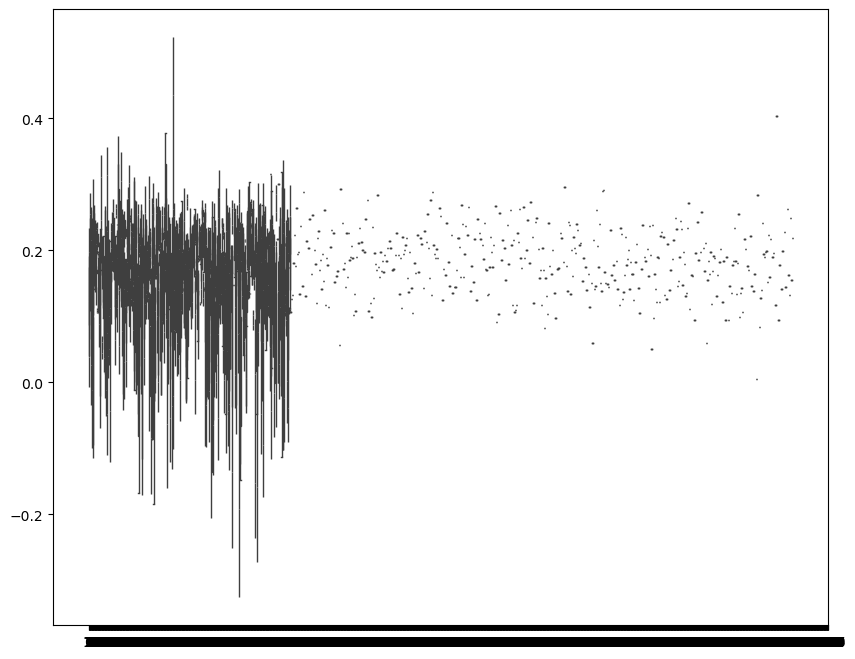

In [ ]:
plt.figure(figsize=(10,8))
plt.boxplot(boxplots.values(), labels=boxplots.keys())
plt.show()

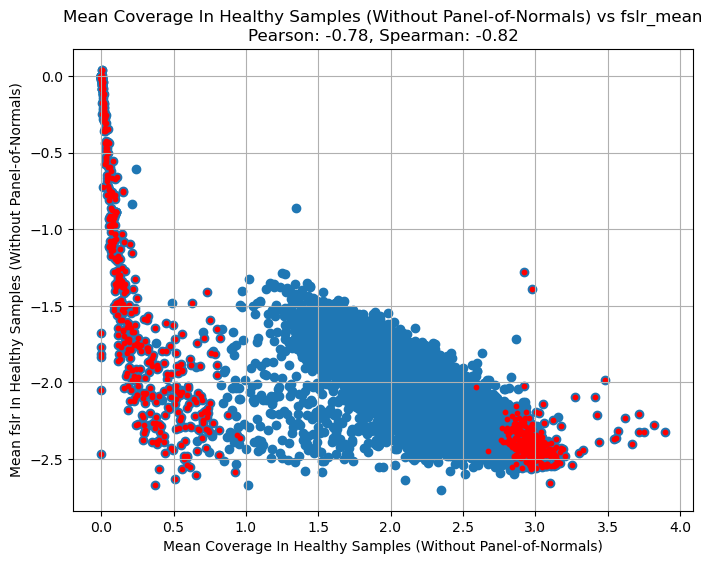

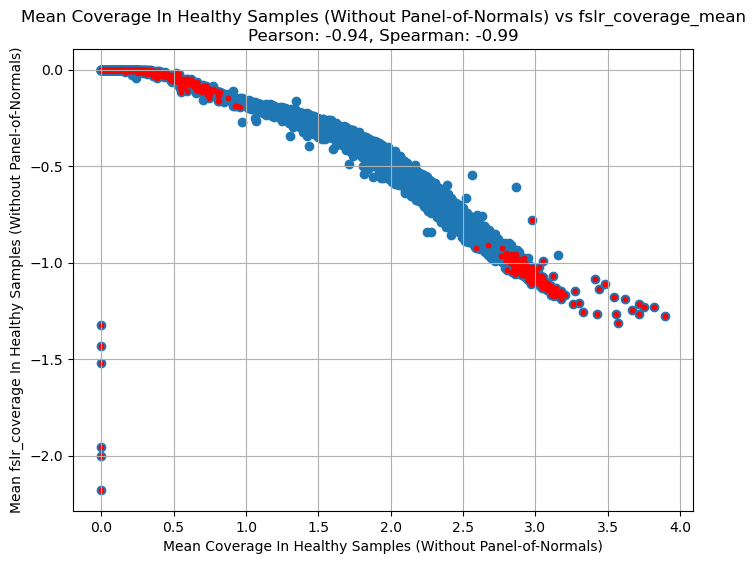

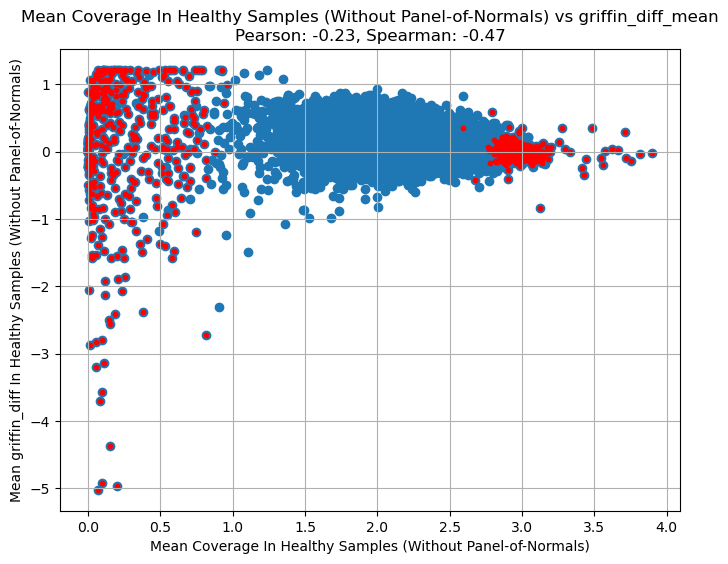

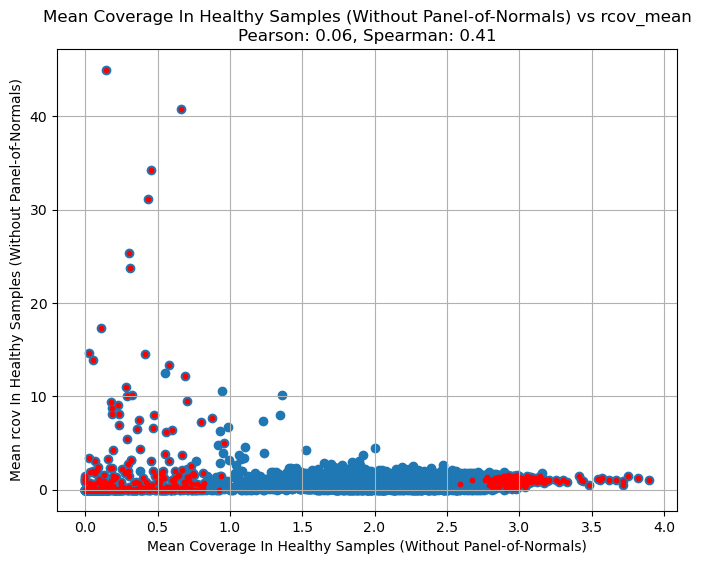

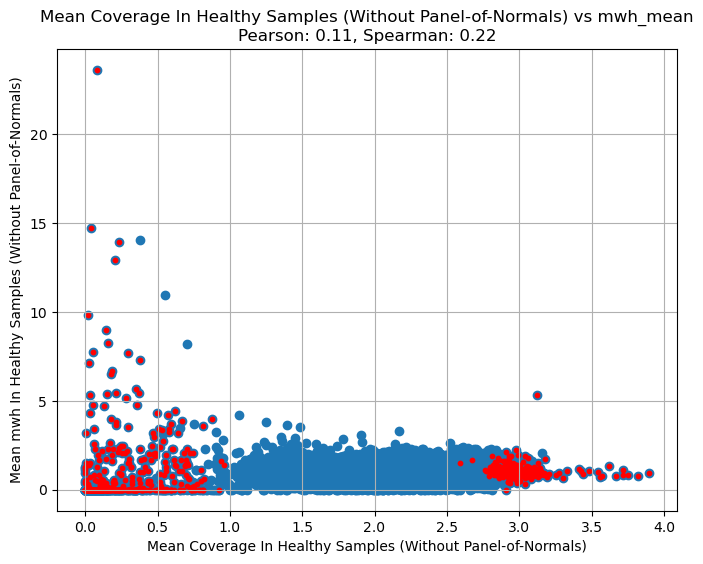

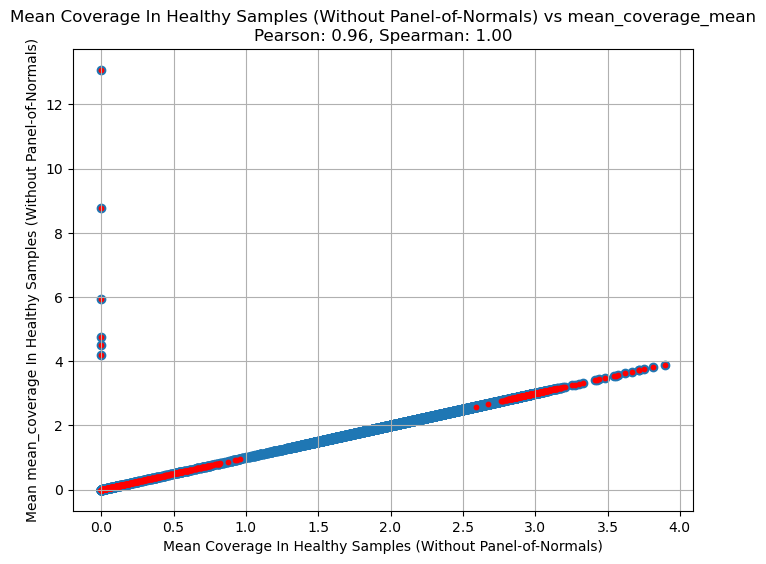

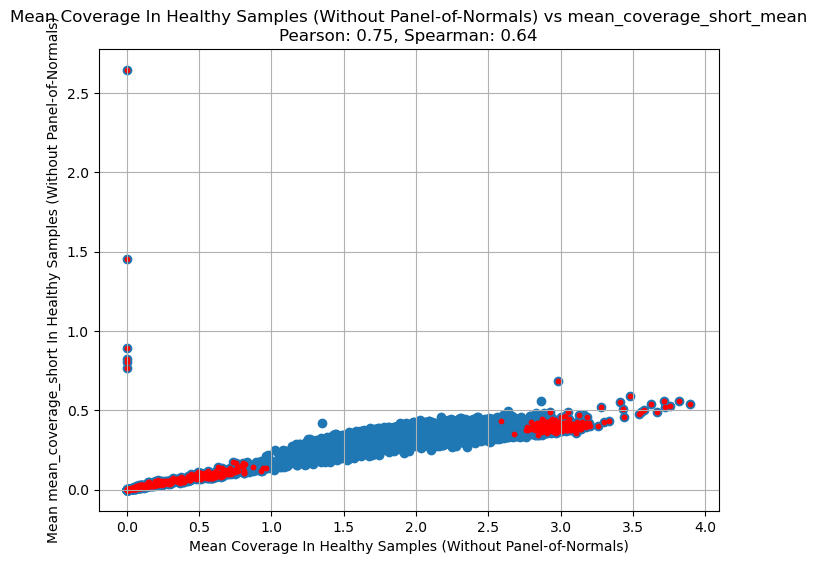

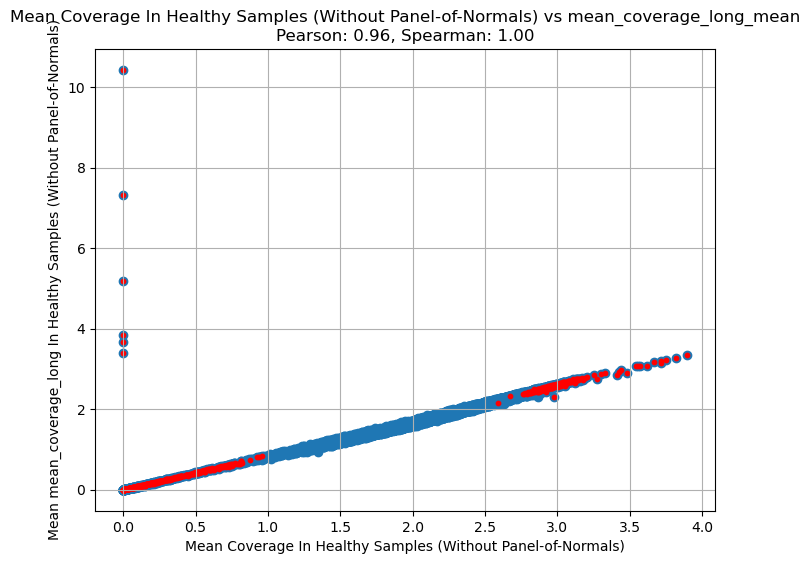

In [ ]:
import scipy.stats
# import deepcopy
from copy import deepcopy

for col in tss_features + ['mean_coverage', 'mean_coverage_short', 'mean_coverage_long']:

    mean_coverage_mean = deepcopy(agg_healthy['mean_coverage_mean'].values)
    mean_coverage_mean[mean_coverage_mean > 4] = 0

    # Calculate Pearson and Spearman correlations
    pearson_corr, _ = scipy.stats.pearsonr(mean_coverage_mean, agg_healthy[col + '_mean'])
    spearman_corr, _ = scipy.stats.spearmanr(mean_coverage_mean, agg_healthy[col + '_mean'])

    # Create the scatter plot
    plt.figure(figsize=(8, 6))
    plt.scatter(mean_coverage_mean, agg_healthy[col + '_mean'])
    plt.scatter(mean_coverage_mean[overlap_indices], agg_healthy.loc[overlap_indices, col + '_mean'], color='red', label='Outlier (overlap)', s=10)

    # Set the title and labels
    plt.title(f'Mean Coverage In Healthy Samples (Without Panel-of-Normals) vs {col + '_mean'}\n'
              f'Pearson: {pearson_corr:.2f}, Spearman: {spearman_corr:.2f}')
    plt.xlabel('Mean Coverage In Healthy Samples (Without Panel-of-Normals)')
    plt.ylabel(f'Mean {col} In Healthy Samples (Without Panel-of-Normals)')
    plt.grid(True)

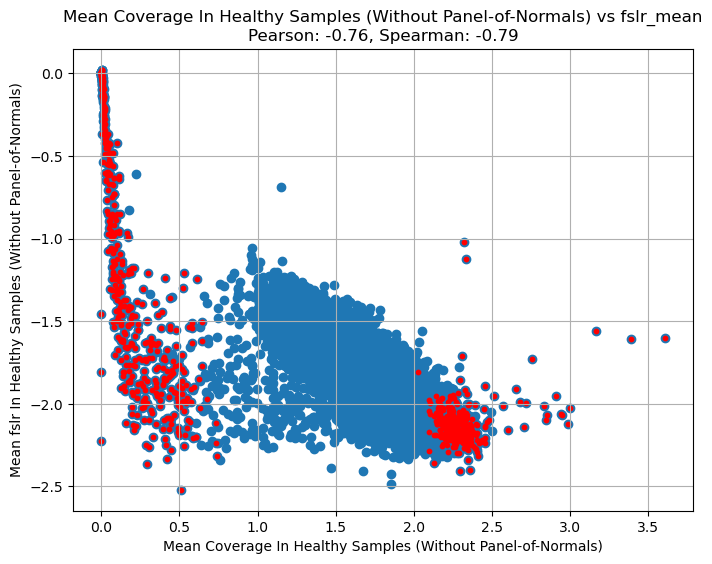

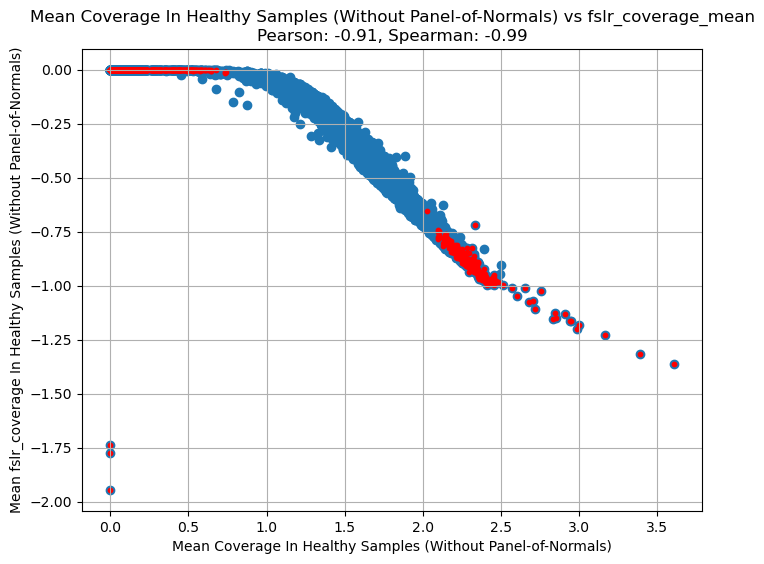

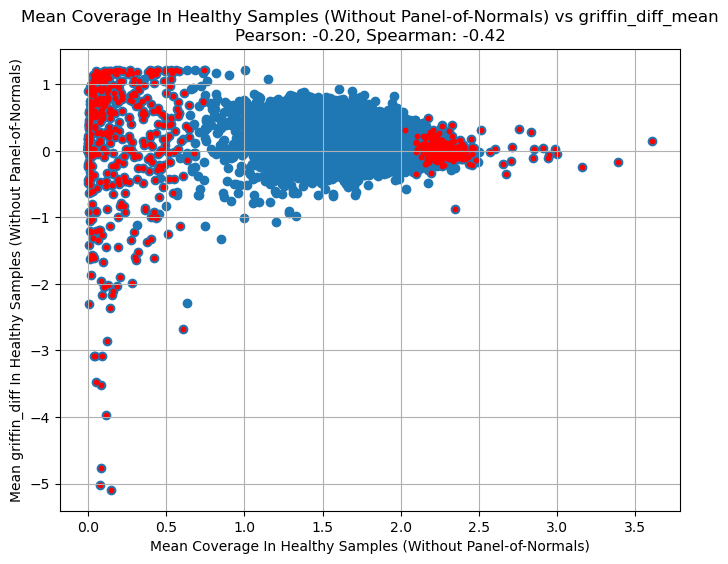

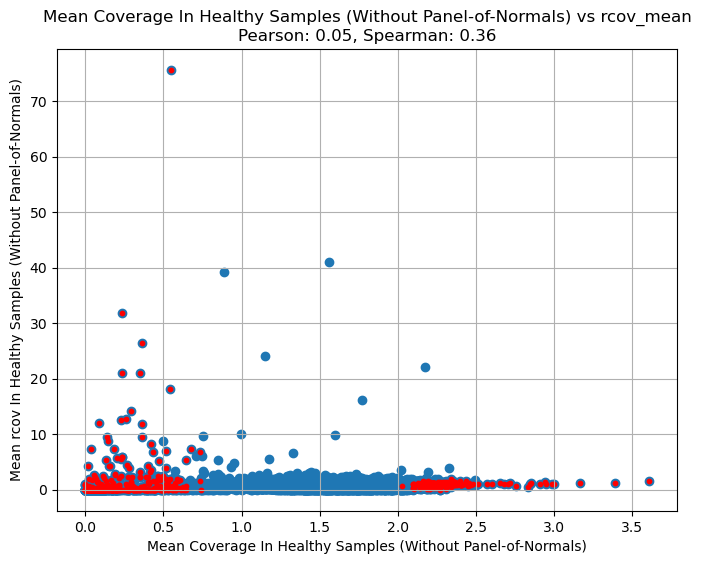

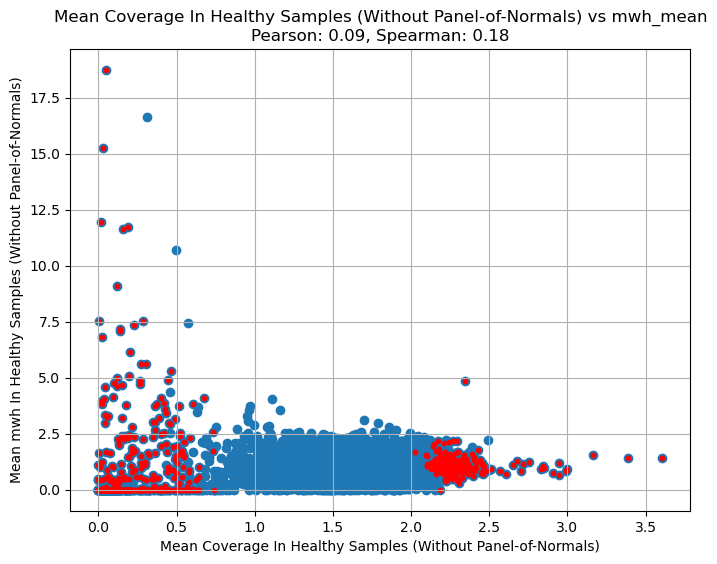

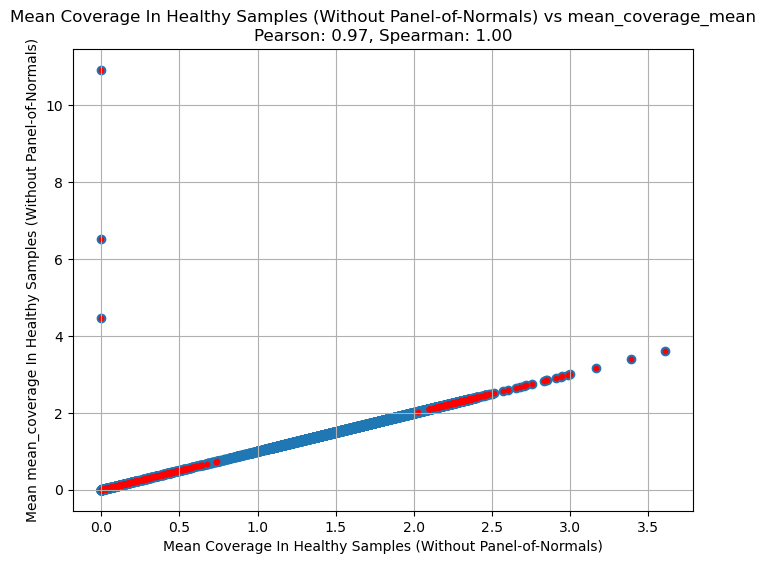

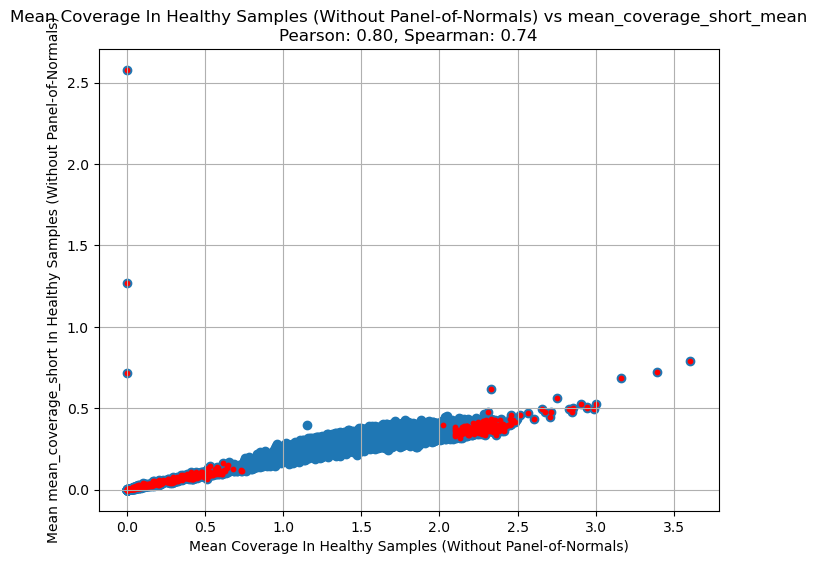

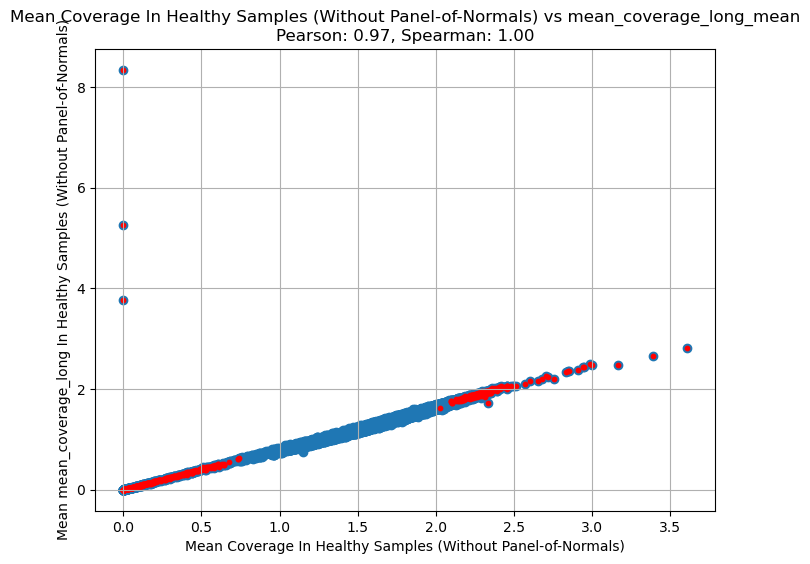

In [ ]:
import scipy.stats
# import deepcopy
from copy import deepcopy

for col in tss_features + ['mean_coverage', 'mean_coverage_short', 'mean_coverage_long']:

    mean_coverage_mean = deepcopy(agg_cancer['mean_coverage_mean'].values)
    mean_coverage_mean[mean_coverage_mean > 4] = 0

    # Calculate Pearson and Spearman correlations
    pearson_corr, _ = scipy.stats.pearsonr(mean_coverage_mean, agg_cancer[col + '_mean'])
    spearman_corr, _ = scipy.stats.spearmanr(mean_coverage_mean, agg_cancer[col + '_mean'])

    # Create the scatter plot
    plt.figure(figsize=(8, 6))
    plt.scatter(mean_coverage_mean, agg_cancer[col + '_mean'])
    plt.scatter(mean_coverage_mean[overlap_indices], agg_cancer.loc[overlap_indices, col + '_mean'], color='red', label='Outlier (overlap)', s=10)

    # Set the title and labels
    plt.title(f'Mean Coverage In Healthy Samples (Without Panel-of-Normals) vs {col + '_mean'}\n'
              f'Pearson: {pearson_corr:.2f}, Spearman: {spearman_corr:.2f}')
    plt.xlabel('Mean Coverage In Healthy Samples (Without Panel-of-Normals)')
    plt.ylabel(f'Mean {col} In Healthy Samples (Without Panel-of-Normals)')
    plt.grid(True)

In [ ]:
# Count number of zeroes in mean_coverage_mean
print(np.sum(agg_pon['mean_coverage_mean'] == 0), np.sum(agg_healthy['mean_coverage_short_mean'] == 0), np.sum(agg_healthy['mean_coverage_long_mean'] == 0))

38 32 28


In [ ]:
# Create a correlation heatmap of agg_pon
# Create a correlation heatmap
plt.figure(figsize=(24, 24))
corr_matrix = agg_pon.drop('chrom', axis=1).corr()
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', cbar_kws={'label': 'Correlation Coefficient'})
plt.title('Correlation Heatmap of Aggregated Features')
plt.tight_layout()
plt.show()

NameError: name 'plt' is not defined

In [ ]:
biomart = pd.read_csv("beds/biomart_10kb.bed", sep="\t", header=None)
biomart.columns = ["chrom", "start", "end", "name", "strand", "gc"]

hk_genes = pd.read_csv("accessory_files/Housekeeping_GenesHuman.csv", sep=';')
hk_genes = hk_genes["Gene.name"].unique().astype(str)
print(f"Number of housekeeping genes: {len(hk_genes)}")

pau_genes = pd.read_csv("beds/pau.bed", sep="\t", header=None)
pau_genes.columns = ["chrom", "start", "end", "name", "strand", "gc"]
pau_genes = pau_genes["name"].unique().astype(str)
print(f"Number of pau genes: {len(pau_genes)}")

# Get the indices of the genes in the biomart file
hk_indices = biomart[biomart["name"].isin(hk_genes)].index
pau_indices = biomart[biomart["name"].isin(pau_genes)].index

# Is there overlap between the hk/pau genes and overlap_indices?
overlap_hk = hk_indices.intersection(overlap_indices)
overlap_pau = pau_indices.intersection(overlap_indices)
print(f"Number of overlapping housekeeping genes: {len(overlap_hk)}")
print(f"Number of overlapping pau genes: {len(overlap_pau)}")

Number of housekeeping genes: 2176
Number of pau genes: 751
Number of overlapping housekeeping genes: 9
Number of overlapping pau genes: 135


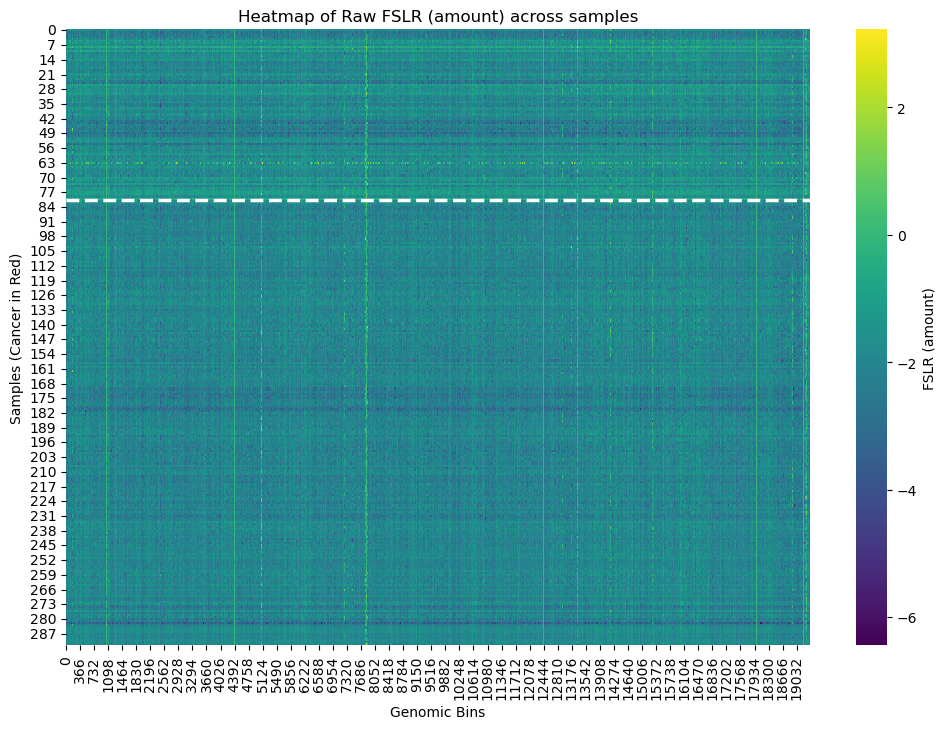

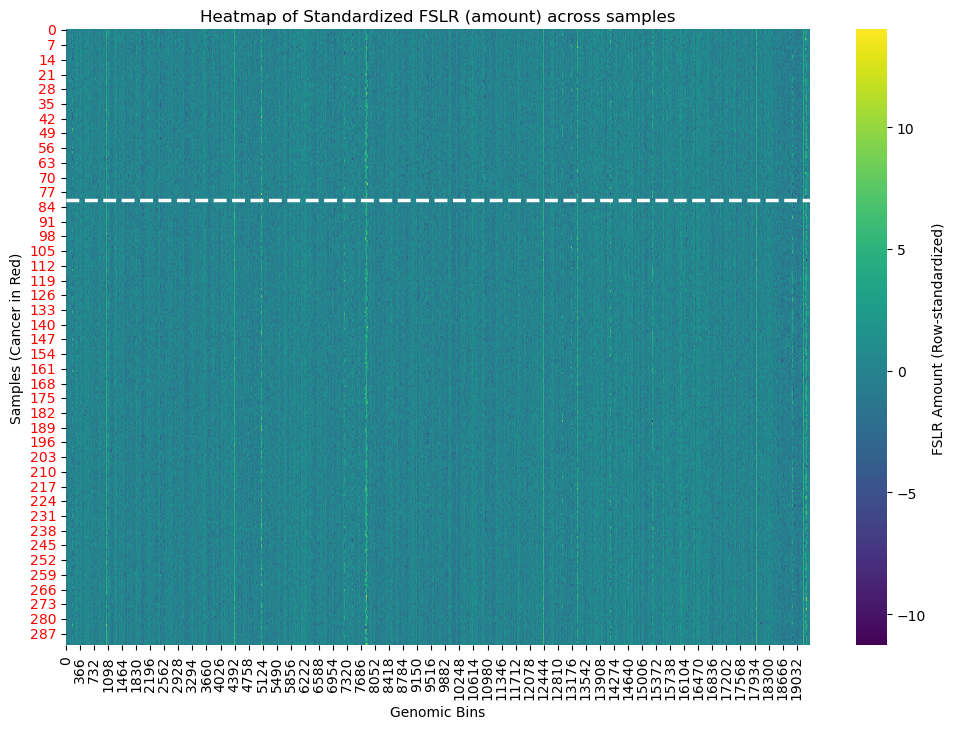

In [ ]:
# Combine the cancer and healthy data

# Remove overlap_indices from feature_arrays_pon['fslr']
non_overlap_indices = np.setdiff1d(np.arange(feature_arrays_pon['fslr'].shape[1]), overlap_indices)

combined_data_raw = np.vstack((
    feature_arrays_cancer['fslr'], 
    feature_arrays_healthy['fslr']
))

# Get the number of cancer samples to know where to draw the line
n_cancer = feature_arrays_cancer['fslr'].shape[0]

# Create a figure and axes for the plot
fig1, ax1 = plt.subplots(figsize=(12, 8))

# Plot the heatmap
sns.heatmap(combined_data_raw, cmap='viridis', cbar_kws={'label': 'FSLR (amount)'}, ax=ax1)

# --- NEW: Add a line to separate the two groups ---
ax1.axhline(y=n_cancer, color='white', linewidth=2.5, linestyle='--')

# --- NEW: Color the y-tick labels for distinction ---
# This is often too cluttered for hundreds of samples, but shown here for demonstration.
# We will color the first n_cancer ticks red.

ax1.set_title('Heatmap of Raw FSLR (amount) across samples')
ax1.set_xlabel('Genomic Bins')
ax1.set_ylabel('Samples (Cancer in Red)')
plt.show()


# --- PLOT 2: Heatmap of Standardized FSLR Data ---

# Standardize each group separately before combining
cancer_standardized = (feature_arrays_cancer['fslr'] - np.mean(feature_arrays_cancer['fslr'], axis=1, keepdims=True)) / np.std(feature_arrays_cancer['fslr'], axis=1, keepdims=True)
healthy_standardized = (feature_arrays_healthy['fslr'] - np.mean(feature_arrays_healthy['fslr'], axis=1, keepdims=True)) / np.std(feature_arrays_healthy['fslr'], axis=1, keepdims=True)

combined_data_std = np.vstack((cancer_standardized, healthy_standardized))

# Create a second figure and axes
fig2, ax2 = plt.subplots(figsize=(12, 8))

# Plot the heatmap
sns.heatmap(combined_data_std, cmap='viridis', cbar_kws={'label': 'FSLR Amount (Row-standardized)'}, ax=ax2)

# --- NEW: Add the same separation line ---
ax2.axhline(y=n_cancer, color='white', linewidth=2.5, linestyle='--')

# --- NEW: Color the y-tick labels again ---
for i, tick in enumerate(ax2.get_yticklabels()):
    if i < n_cancer:
        tick.set_color('red')

ax2.set_title('Heatmap of Standardized FSLR (amount) across samples')
ax2.set_xlabel('Genomic Bins')
ax2.set_ylabel('Samples (Cancer in Red)')
plt.show()

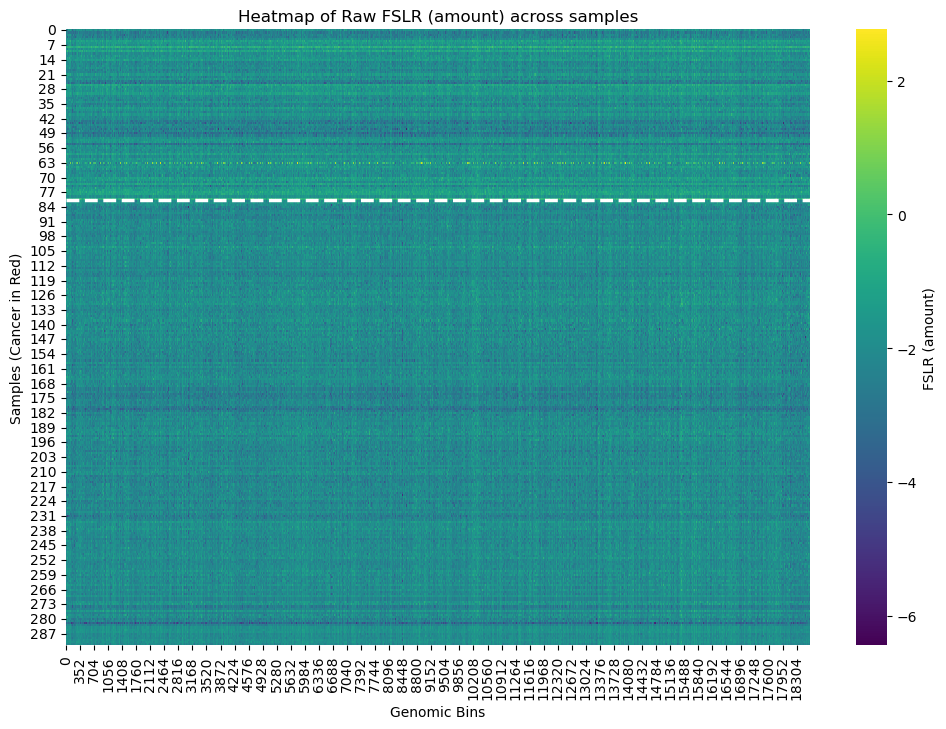

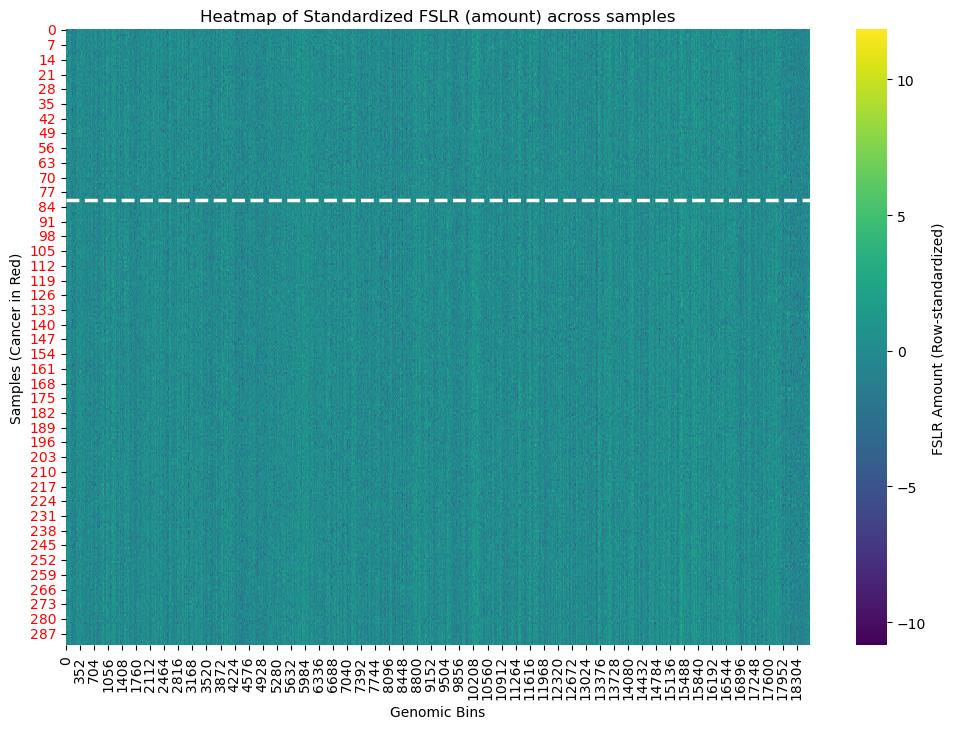

In [ ]:
# Combine the cancer and healthy data

# Remove overlap_indices from feature_arrays_pon['fslr']
non_overlap_indices = np.setdiff1d(np.arange(feature_arrays_pon['fslr'].shape[1]), overlap_indices)

combined_data_raw = np.vstack((
    feature_arrays_cancer['fslr'][:, non_overlap_indices], 
    feature_arrays_healthy['fslr'][:, non_overlap_indices]
))

# Get the number of cancer samples to know where to draw the line
n_cancer = feature_arrays_cancer['fslr'].shape[0]

# Create a figure and axes for the plot
fig1, ax1 = plt.subplots(figsize=(12, 8))

# Plot the heatmap
sns.heatmap(combined_data_raw, cmap='viridis', cbar_kws={'label': 'FSLR (amount)'}, ax=ax1)

# --- NEW: Add a line to separate the two groups ---
ax1.axhline(y=n_cancer, color='white', linewidth=2.5, linestyle='--')

# --- NEW: Color the y-tick labels for distinction ---
# This is often too cluttered for hundreds of samples, but shown here for demonstration.
# We will color the first n_cancer ticks red.

ax1.set_title('Heatmap of Raw FSLR (amount) across samples')
ax1.set_xlabel('Genomic Bins')
ax1.set_ylabel('Samples (Cancer in Red)')
plt.show()


# --- PLOT 2: Heatmap of Standardized FSLR Data ---

# Standardize each group separately before combining
cancer_standardized = (feature_arrays_cancer['fslr'][:, non_overlap_indices] - np.mean(feature_arrays_cancer['fslr'][:, non_overlap_indices], axis=1, keepdims=True)) / np.std(feature_arrays_cancer['fslr'][:, non_overlap_indices], axis=1, keepdims=True)
healthy_standardized = (feature_arrays_healthy['fslr'][:, non_overlap_indices] - np.mean(feature_arrays_healthy['fslr'][:, non_overlap_indices], axis=1, keepdims=True)) / np.std(feature_arrays_healthy['fslr'][:, non_overlap_indices], axis=1, keepdims=True)

combined_data_std = np.vstack((cancer_standardized, healthy_standardized))

# Create a second figure and axes
fig2, ax2 = plt.subplots(figsize=(12, 8))

# Plot the heatmap
sns.heatmap(combined_data_std, cmap='viridis', cbar_kws={'label': 'FSLR Amount (Row-standardized)'}, ax=ax2)

# --- NEW: Add the same separation line ---
ax2.axhline(y=n_cancer, color='white', linewidth=2.5, linestyle='--')

# --- NEW: Color the y-tick labels again ---
for i, tick in enumerate(ax2.get_yticklabels()):
    if i < n_cancer:
        tick.set_color('red')

ax2.set_title('Heatmap of Standardized FSLR (amount) across samples')
ax2.set_xlabel('Genomic Bins')
ax2.set_ylabel('Samples (Cancer in Red)')
plt.show()

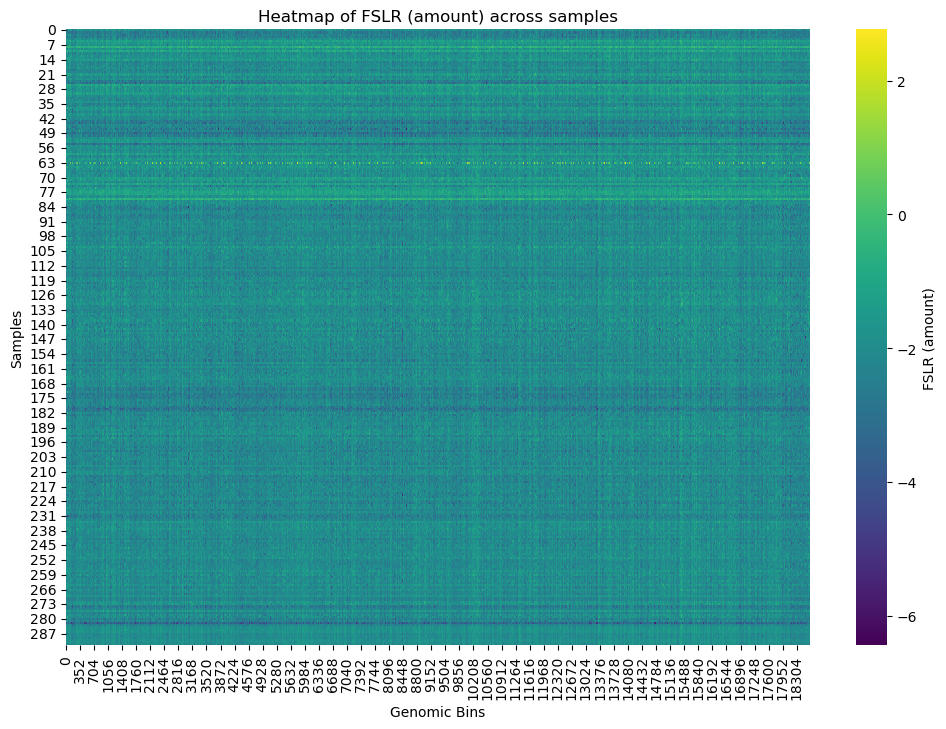

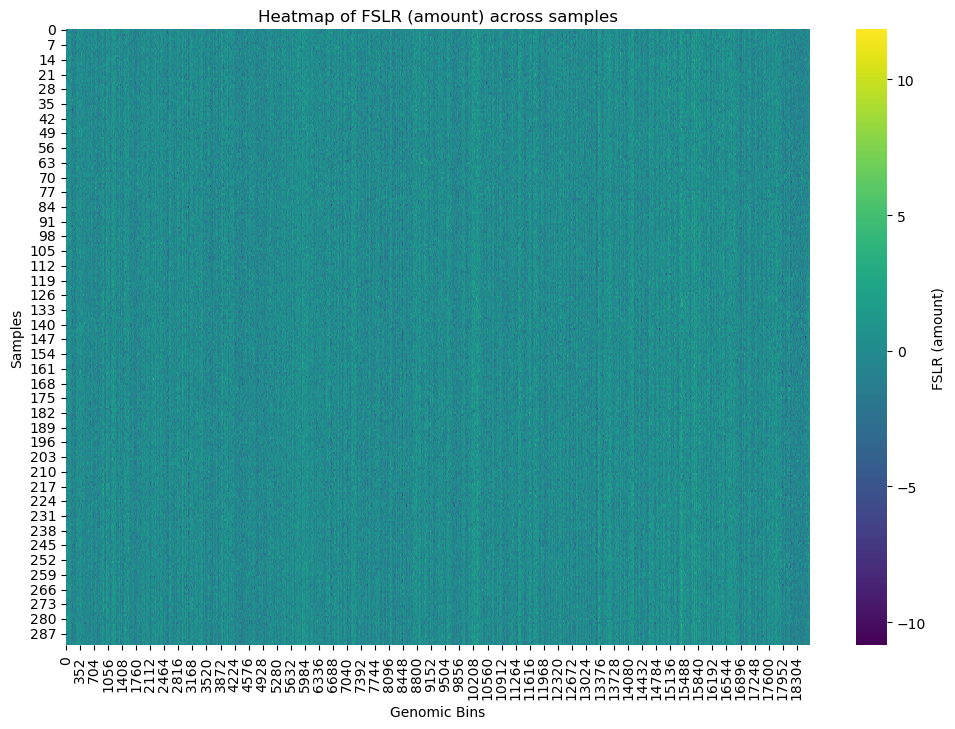

In [ ]:
plt.figure(figsize=(12, 8))

# Remove overlap_indices from feature_arrays_pon['fslr']
non_overlap_indices = np.setdiff1d(np.arange(feature_arrays_pon['fslr'].shape[1]), overlap_indices)

# For each row in feature_arrays_pon['fslr'][:, non_overlap_indices], make the mean 0 and std 1
# feature_arrays_pon['fslr'][:, non_overlap_indices] = (feature_arrays_pon['fslr'][:, non_overlap_indices] - np.mean(feature_arrays_pon['fslr'][:, non_overlap_indices], axis=1, keepdims=True)) / np.std(feature_arrays_pon['fslr'][:, non_overlap_indices], axis=1, keepdims=True)

sns.heatmap(np.vstack((feature_arrays_cancer['fslr'][:, non_overlap_indices], feature_arrays_healthy['fslr'][:, non_overlap_indices])), cmap='viridis', cbar_kws={'label': 'FSLR (amount)'})
plt.title(f'Heatmap of FSLR (amount) across samples')
plt.xlabel('Genomic Bins')
plt.ylabel('Samples')
plt.show()

plt.figure(figsize=(12, 8))

sns.heatmap(np.vstack(( (feature_arrays_cancer['fslr'][:, non_overlap_indices] - np.mean(feature_arrays_cancer['fslr'][:, non_overlap_indices], axis=1, keepdims=True)) / np.std(feature_arrays_cancer['fslr'][:, non_overlap_indices], axis=1, keepdims=True),
                       (feature_arrays_healthy['fslr'][:, non_overlap_indices] - np.mean(feature_arrays_healthy['fslr'][:, non_overlap_indices], axis=1, keepdims=True)) / np.std(feature_arrays_healthy['fslr'][:, non_overlap_indices], axis=1, keepdims=True))), cmap='viridis', cbar_kws={'label': 'FSLR (amount)'})
plt.title(f'Heatmap of FSLR (amount) across samples')
plt.xlabel('Genomic Bins')
plt.ylabel('Samples')
plt.show()

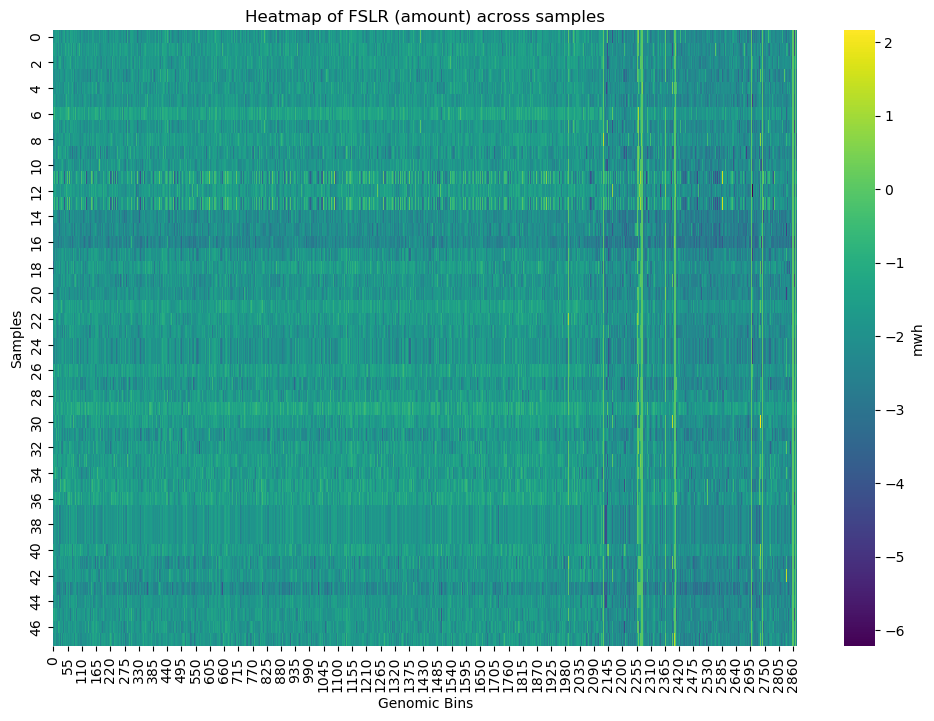

In [ ]:
plt.figure(figsize=(12, 8))

sns.heatmap(np.hstack((feature_arrays_pon['fslr'][:, hk_indices], feature_arrays_pon['fslr'][:, pau_indices])), cmap='viridis', cbar_kws={'label': 'FSLR (amount)'})
plt.title(f'Heatmap of FSLR (amount) across samples')
plt.xlabel('Genomic Bins')
plt.ylabel('Samples')
plt.show()

In [ ]:
feature_arrays_healthy


{'fslr': array([[-3.08121681,  0.        , -1.55168843, ..., -2.47910571,
         -2.01380801, -3.15304399],
        [-1.58052444,  0.        , -1.96305609, ..., -1.91988528,
         -2.35245895, -1.03843021],
        [-1.65144432,  0.        ,  0.20080194, ..., -1.7501334 ,
         -2.32474923, -1.65850735],
        ...,
        [-1.741467  , -0.96670789, -1.22635114, ..., -1.98246586,
         -2.12618661, -1.52088141],
        [-2.43148446, -0.81653088, -1.63430524, ..., -1.77826583,
         -1.92535794, -1.31876528],
        [-1.90928245, -0.86112607, -1.79473543, ..., -2.29831409,
         -2.27947712, -2.83603525]], shape=(212, 19376)),
 'fslr_coverage': array([[ 0.        ,  0.        ,  0.        , ..., -0.34789811,
         -0.40258023,  0.        ],
        [ 0.        ,  0.        ,  0.        , ..., -0.5656323 ,
         -0.55111058,  0.        ],
        [ 0.        ,  0.        ,  0.        , ...,  0.        ,
         -0.26267093,  0.        ],
        ...,
        [

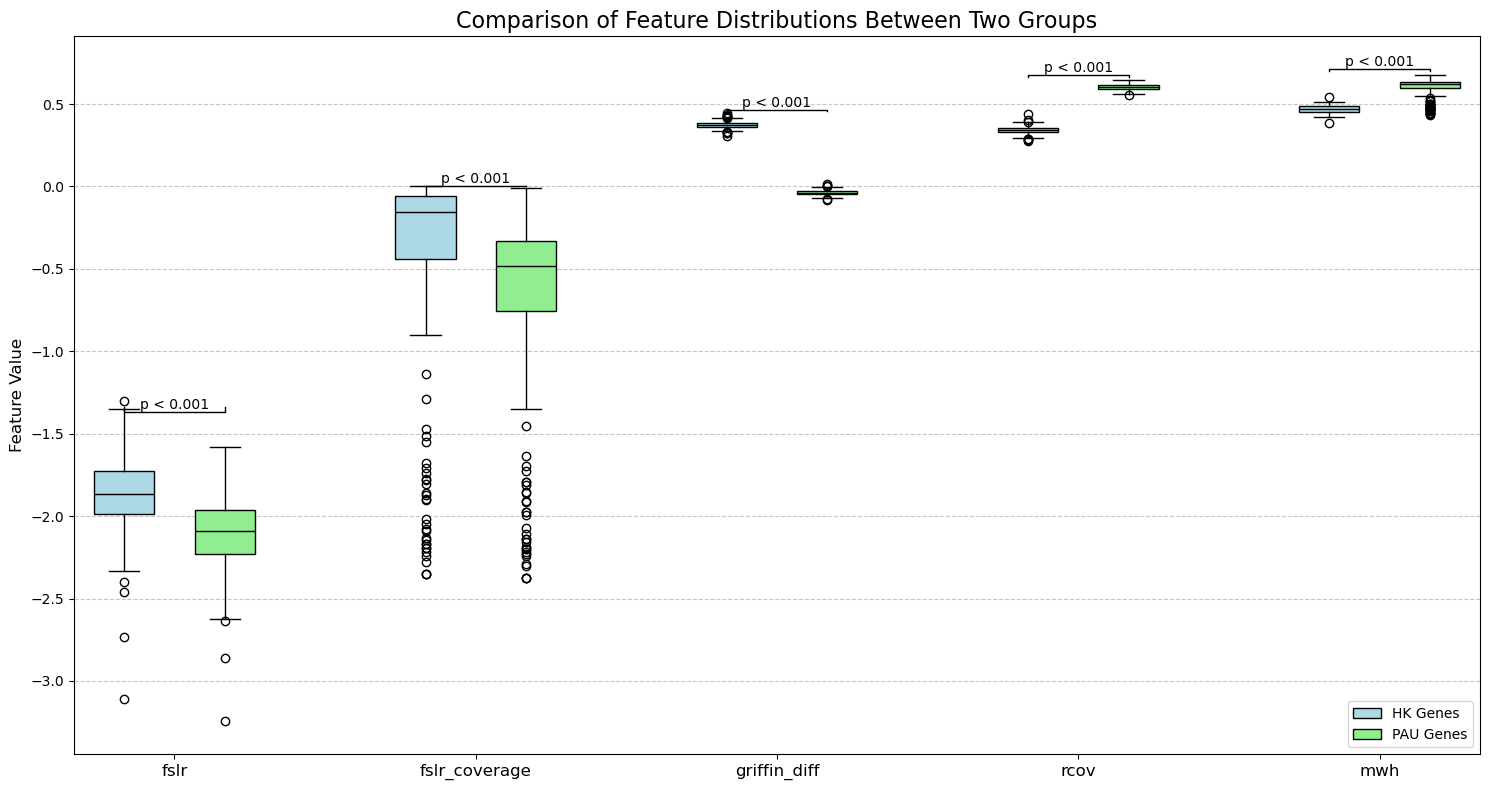

In [ ]:
# Figure 1C
from scipy.stats import mannwhitneyu

data_to_plot = []
p_values = []
stats = []

for name in tss_features:
    matrix = feature_arrays_healthy[name]

    if name == 'rcov' or name == 'mwh':
        matrix = np.log1p(matrix)
    
    # Extract and flatten the data for each group
    group1_data = matrix[:, hk_indices].mean(axis=1)
    group2_data = matrix[:, pau_indices].mean(axis=1)
    
    # Store the data for plotting
    data_to_plot.extend([group1_data, group2_data])
    
    # Perform the Mann-Whitney U test
    stat, p_val = mannwhitneyu(group1_data, group2_data, alternative='two-sided')
    stats.append(stat)
    p_values.append(p_val)

## 3. Create the grouped boxplot figure
fig, ax = plt.subplots(figsize=(15, 8))

# Define positions for the boxes on the x-axis
# We create a gap between each pair of boxes
positions = []
for i in range(len(tss_features)):
    positions.extend([i*3 + 1, i*3 + 2])

# Plot all boxplots at once
bp = ax.boxplot(data_to_plot, 
                positions=positions, 
                widths=0.6, 
                patch_artist=True, # Important for filling with color
                medianprops=dict(color="black"))

## 4. Customize colors and add legend
colors = ['lightblue', 'lightgreen']
for i, box in enumerate(bp['boxes']):
    box.set_facecolor(colors[i % 2])

# Add a legend
ax.legend([bp["boxes"][0], bp["boxes"][1]], ['HK Genes', 'PAU Genes'], loc='lower right')

## 5. Annotate with p-values
for i in range(len(tss_features)):
    pos1 = i*3 + 1
    pos2 = i*3 + 2
    
    # Get the data for the current pair
    data1 = data_to_plot[i*2]
    data2 = data_to_plot[i*2 + 1]
    
    # Find the maximum y-value for positioning the annotation bar
    max_y = max(np.max(data1), np.max(data2))
    bar_height = max_y * 1.05 # Position bar 5% above the max value
    bar_tips = bar_height * 0.98

    p_val = p_values[i]
    
    # Format the p-value string
    if p_val < 0.001:
        p_text = "p < 0.001"
    else:
        p_text = f"p = {p_val:.30f}"

    # # Add the statistic to the text
    # stat_text = f"U = {stat:.1f}"
    # p_text = f"{p_text}\n{stat_text}"

    # Draw the bar and the text
    ax.plot([pos1, pos1, pos2, pos2], [bar_tips, bar_height, bar_height, bar_tips], lw=1, c='k')
    ax.text((pos1 + pos2) / 2, bar_height, p_text, ha='center', va='bottom', color='k', fontsize=10)

## 6. Final plot adjustments
ax.set_xticks([i*3 + 1.5 for i in range(len(tss_features))])
ax.set_xticklabels(tss_features, fontsize=12)
ax.set_ylabel('Feature Value', fontsize=12)
ax.set_title('Comparison of Feature Distributions Between Two Groups', fontsize=16)
ax.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()